# Hitting Times

A **hitting time** answers: *how long until this random process first reaches some level?*

It is one of the most-asked questions about a random process, under many names:

- How long until a stock first touches \$120?
- How long until an insurer's reserves first hit 0? (*ruin time*)
- How long until a gambler is up \$50, or broke?
- How long until a queue first reaches 10 people?

`hitting_time(process, level=...)` gives you that as a random variable, which you can then simulate and plot like anything else.

In [1]:
from symbulate import *
import numpy as np

## The basic idea

Start with a Brownian motion -- a random wander that begins at 0 -- and ask when it first reaches 1.

`max_time` is how long to keep looking before giving up. It is needed because the level might never be reached, and in that case the answer is `inf` (infinity).

In [2]:
B = BrownianMotion()
T = hitting_time(B, level=1, max_time=20)

It is a random variable, so simulate it. Each value is how long that particular random path took to reach 1.

In [3]:
times = T.sim(1000)
times

0,0.9999019622802734
1,0.6906246185302735
2,inf
3,0.38118782043457033
4,1.6999996185302733
5,7.017296981811528
6,4.999999618530275
7,2.8127582550048826
8,1.2124996185302734
...,...
999,inf


Look closely and some of those values are `inf`. Those are paths that never got to 1 within the 20 units of time we allowed. That is not a failure -- it is the honest answer, and it is a real feature of hitting times. Some paths simply wander the wrong way the whole time.

To plot the ones that *did* arrive, filter the infinities out first with `filter_leq`:

## The distribution of hitting times

The shape is worth seeing. Most paths reach the level early, but the tail is enormously long -- a few take almost the whole window.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


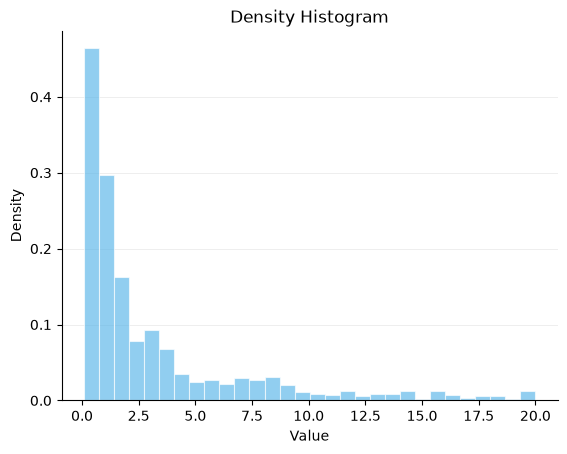

In [4]:
T.sim(1000).filter_leq(20).plot()

That tail is so long that the **average is infinite**, in theory. In practice the simulated average is meaningless: it jumps around wildly depending on whether a few huge values happened to turn up. The *median* is the number to quote instead.

In [5]:
values = np.array([v for v in T.sim(1000)], dtype=float)
reached = values[np.isfinite(values)]

print(f"reached level 1 within 20:  {len(reached) / len(values):.1%}")
print(f"median time to reach it:    {np.median(reached):.2f}")
print(f"average (do not trust it):  {reached.mean():.2f}")

reached level 1 within 20:  81.2%
median time to reach it:    1.54
average (do not trust it):  3.23


## Checking it against the exact answer

Brownian motion is one of the few processes where the answer is known on paper. The chance of reaching level `a` by time `t` is exactly

$$2\,\Phi\!\left(\frac{-a}{\text{scale}\sqrt{t}}\right)$$

where $\Phi$ is the normal CDF. Comparing simulation to formula:

In [6]:
import scipy.stats as st

for max_time in [1, 4, 16]:
    simulated = hitting_time(B, level=1, max_time=max_time)
    got = np.mean(np.isfinite([v for v in simulated.sim(5000)]))
    exact = 2 * st.norm.cdf(-1 / np.sqrt(max_time))
    print(f"by time {max_time:>2}:  simulated {got:.3f}   exact {exact:.3f}")

by time  1:  simulated 0.323   exact 0.317


by time  4:  simulated 0.626   exact 0.617


by time 16:  simulated 0.804   exact 0.803


## Why this is harder than it looks

Here is the catch, and it is the whole reason this needs a real algorithm rather than a loop.

A sample path is only ever worked out at the times you ask about. In between two of those times it is **not** a straight line -- it wiggles. So the path can pop above the level and come back down without either of the times you looked at noticing.

The cell below shows this happening. It looks at a path every 1 unit of time, which spots nothing, then looks every 0.01 and finds the level was reached after all.

In [7]:
path = BrownianMotion().draw()
level = 0.5

coarse = [t for t in np.arange(0, 5.01, 1.0) if path(t) >= level]
fine = [t for t in np.arange(0, 5.01, 0.01) if path(t) >= level]

print(f"checking every 1.00: reached the level at {len(coarse)} of the times looked at")
print(f"checking every 0.01: reached the level at {len(fine)} of the times looked at")

checking every 1.00: reached the level at 1 of the times looked at
checking every 0.01: reached the level at 153 of the times looked at


Checking more finely always finds more crossings, and you can never be sure you have looked finely enough. Simply scanning would report hitting times that are **too late**, or miss crossings completely.

`hitting_time` avoids the problem instead of out-running it. For a Brownian motion there is a formula for the *probability* that the path crossed a level between two known values:

$$P(\text{crossed}) = \exp\!\left(\frac{-2\,(a - x_0)(a - x_1)}{\text{rate} \times (t_1 - t_0)}\right)$$

So rather than looking harder, it flips a coin weighted by that probability. Nothing can hide. When the coin says a crossing happened, it cuts the stretch in half over and over to work out when.

The proof that this works: for Brownian motion the answer should not depend on how finely you scan. Below, `step` is how far ahead it looks at a time -- from one single giant stride down to small ones. All three agree with each other and with the exact answer.

In [8]:
exact = 2 * st.norm.cdf(-1 / np.sqrt(4))
print(f"exact answer: {exact:.3f}\n")

for step in [4.0, 1.0, 0.25]:
    T_step = hitting_time(B, level=1, max_time=4, step=step)
    got = np.mean(np.isfinite([v for v in T_step.sim(2000)]))
    print(f"step = {step:<5} -> {got:.3f}")

exact answer: 0.617

step = 4.0   -> 0.601


step = 1.0   -> 0.616


step = 0.25  -> 0.608


## Falling to a level works too

You do not have to say which direction. If the path starts *above* the level, it looks for the first time it falls to it. By symmetry, reaching -1 should be just as likely as reaching +1.

In [9]:
up = hitting_time(B, level=1, max_time=4)
down = hitting_time(B, level=-1, max_time=4)

for name, T_dir in [("reach +1", up), ("reach -1", down)]:
    got = np.mean(np.isfinite([v for v in T_dir.sim(2000)]))
    print(f"{name}: {got:.3f}")

reach +1: 0.615


reach -1: 0.616


## A more realistic question

Put it together with a stock price. A share is worth \$100 today and you want to sell at \$120. How long might that take?

In [10]:
stock = GeometricBrownianMotion(initial_value=100, growth_rate=0.05, scale=0.3)
wait = hitting_time(stock, level=120, max_time=10)

waits = np.array([v for v in wait.sim(1000)], dtype=float)
sold = waits[np.isfinite(waits)]

print(f"hit $120 within 10 years:  {len(sold) / len(waits):.1%}")
print(f"median wait, if it did:    {np.median(sold):.2f} years")

hit $120 within 10 years:  84.6%
median wait, if it did:    0.54 years


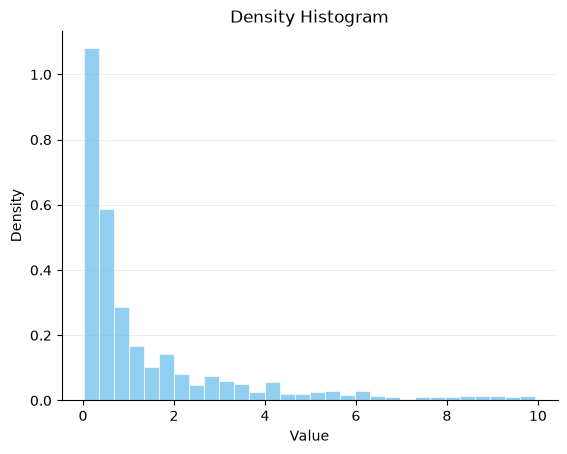

In [11]:
wait.sim(1000).filter_leq(10).plot()

## Two things to know

**1. `step` controls precision, not just speed.** Whether the level was reached, and which `step`-sized stretch it happened in, is exact for Brownian motion. But pinning down *where inside* that stretch is approximate and leans slightly late. So the reported time is good to about one `step`. Use a smaller `step` if you need sharp individual times; the default (the window split into 100) is fine for plotting a distribution.

**2. Only Gaussian processes so far.** `BrownianMotion`, `BrownianBridge`, `OrnsteinUhlenbeck`, `FractionalBrownianMotion`, `GeometricBrownianMotion`, and any `GaussianProcess` you build yourself. For Brownian motion and Brownian bridges the crossing formula is exact; for the others it is a close approximation that improves with a smaller `step`.

Other kinds of process -- random walks, Markov chains, queues, general diffusions -- need different handling and are not built yet. Asking anyway gives a clear message rather than a wrong number:

In [12]:
try:
    hitting_time(RandomWalk(p=0.5).draw(), level=5)
except NotImplementedError as error:
    print(error)

hitting_time currently only works for Gaussian processes -- BrownianMotion, BrownianBridge, OrnsteinUhlenbeck, FractionalBrownianMotion, GeometricBrownianMotion, or a GaussianProcess you built yourself. It was given a RandomWalkResult, which needs different handling: a discrete-time or jump process (a random walk, Markov chain, or queue) can be checked step by step, and a DiffusionProcess needs its own approximation. Neither is built yet.
